#**3MTT KNN Mini Project**

### Loading a Wine Quality Dataset with a 'quality' column

This code loads a popular 'Wine Quality' dataset (Red Wine) from the UCI Machine Learning Repository, which explicitly includes a 'quality' column, unlike the previously loaded `wine.csv`.

In [45]:
import pandas as pd

# URL for the UCI Red Wine Quality dataset
# This dataset is commonly used for predicting wine quality.
wine_quality_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

# Load the dataset. The separator is typically a semicolon for this dataset.
try:
    wine_quality = pd.read_csv(wine_quality_url, sep=';')
    print("Successfully loaded Wine Quality Dataset.")
    display(wine_quality.head())
    print("Columns in the new dataset:")
    print(wine_quality.columns)
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure you have an active internet connection or try a local file path if you have downloaded the dataset.")

Successfully loaded Wine Quality Dataset.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Columns in the new dataset:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [46]:
print("Missing values in 'wine' DataFrame:")
print(wine_quality.isnull().sum())

Missing values in 'wine' DataFrame:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Split data into training and testing sets (80/20 recommended)

In [47]:
from enum import unique
from sklearn.model_selection import train_test_split

# Assuming 'Price' is the target variable. If not, please change 'Price' to the correct column name.
X = wine_quality.drop('quality', axis=1)
y = wine_quality['quality']

X_train, X_test, y_train, y_test = train_test_split(
     X, y, random_state=11, test_size=0.2)
unique_values = y_train.unique()
print(unique_values)

[6 5 7 4 3 8]


Apply StandardScaler or MinMaxScaler to normalize features

In [48]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easier inspection (optional, but good for understanding)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("X_train_scaled (first 5 rows):")
display(X_train_scaled_df.head())

print("X_test_scaled (first 5 rows):")
display(X_test_scaled_df.head())

X_train_scaled (first 5 rows):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.439279,-0.717405,1.523468,1.577926,-0.165005,-0.945013,-0.807972,-0.124360,-0.192892,-0.521821,1.941683
1,-0.475394,-0.100896,-1.291049,-0.607992,-0.080614,-0.275309,-0.469904,-0.731997,0.326494,-0.699496,0.079112
2,-1.161398,-0.941590,-0.421107,0.522655,-0.270493,-0.083965,-0.224037,-0.614733,1.624960,-0.817947,2.127941
3,-0.475394,-0.044850,0.755873,-0.155733,-0.017320,-0.753669,-0.254770,0.238089,1.754806,-0.284920,0.079112
4,1.010949,-1.389960,0.960565,-0.532615,-0.797938,-1.040685,-1.023106,0.344692,-1.751050,0.781134,-0.200274


X_test_scaled (first 5 rows):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.246726,-1.950422,0.653527,-0.231109,-0.819035,2.116491,0.636499,-0.401528,0.131725,1.610287,0.824141
1,-0.246726,-1.109729,-0.216415,-0.607992,-0.228298,0.203051,-0.039636,-0.268274,-0.127968,-0.048019,-1.038431
2,-1.733069,1.048052,-0.421107,-0.758745,1.543914,-0.849341,0.482832,-1.494207,2.014499,-0.284920,0.544755
3,-0.075224,-0.829497,0.244142,-0.004980,-0.165005,0.777083,0.759433,-0.273604,-0.257815,1.136485,0.544755
4,-1.561568,-1.221821,2.598102,8.587938,-0.291591,0.681411,1.404834,0.008893,0.521264,-1.054848,0.079112


Initialize and train KNeighborsClassifier with an initial k value

### Initialize and Train KNeighborsClassifier

Now, we'll initialize a `KNeighborsClassifier` model. We'll start with `n_neighbors=5` as a common default value. This parameter dictates how many nearest data points are considered when making a prediction for a new data point. After initialization, the model will be trained on the scaled training features (`X_train_scaled`) and their corresponding target values (`y_train`).

In [49]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier with k=5
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using the scaled training data
knn_model.fit(X_train_scaled, y_train)

print("KNeighborsClassifier model initialized and trained successfully with n_neighbors=5.")

KNeighborsClassifier model initialized and trained successfully with n_neighbors=5.


Test different k values (1, 3, 5, 7, 9, 11) using cross-validation

### Optimize `k` value using GridSearchCV

We will use `GridSearchCV` to perform a systematic search for the best `k` parameter for our `KNeighborsClassifier`. This involves evaluating the model with different `k` values (1, 3, 5, 7, 9, 11) using cross-validation on the training set. The model's performance will be measured by its accuracy.

In [50]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11]}

# Initialize KNeighborsClassifier
knn = KNeighborsClassifier()

# Initialize GridSearchCV
# We'll use 5-fold cross-validation (cv=5) and 'accuracy' as the scoring metric.
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Print the best k value and its corresponding accuracy score
print(f"Best k value: {grid_search.best_params_['n_neighbors']}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Store the best model
best_knn_model = grid_search.best_estimator_

Best k value: 1
Best cross-validation accuracy: 0.6216


### Evaluate the Best KNN Model on the Test Set

After identifying the best `k` value through cross-validation, it's crucial to evaluate the performance of this optimized model on the unseen test set to get a realistic measure of its generalization ability.

In [51]:
from sklearn.metrics import accuracy_score

# Make predictions on the scaled test set using the best model
y_pred_test = best_knn_model.predict(X_test_scaled)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Test set accuracy with best k ({best_knn_model.n_neighbors}): {test_accuracy:.4f}")

Test set accuracy with best k (1): 0.6062


### Plotting k vs. Accuracy

To identify the optimal `k` value more clearly, we can visualize the cross-validation accuracy scores for each `k` tested by `GridSearchCV`.

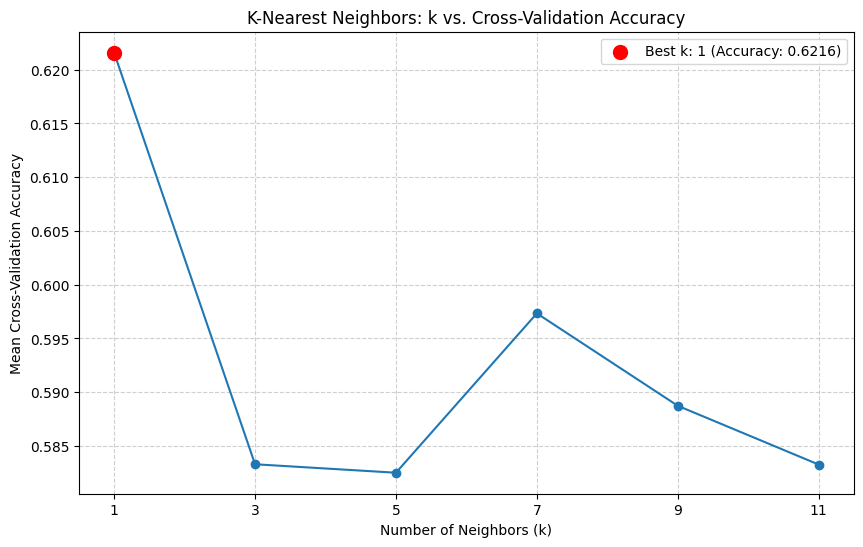

In [52]:
import matplotlib.pyplot as plt

# Get the results from GridSearchCV
results = grid_search.cv_results_
k_values = param_grid['n_neighbors']
mean_test_scores = results['mean_test_score']

# Find the best k and its score for plotting
best_k_value = grid_search.best_params_['n_neighbors']
best_accuracy = grid_search.best_score_

# Plot k vs. accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_test_scores, marker='o', linestyle='-')
plt.scatter(best_k_value, best_accuracy, color='red', s=100, zorder=5, label=f'Best k: {best_k_value} (Accuracy: {best_accuracy:.4f})')
plt.title('K-Nearest Neighbors: k vs. Cross-Validation Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Evaluate final model using accuracy, precision, recall, F1-score, and confusion matrix

### Comprehensive Model Evaluation

Beyond simple accuracy, evaluating a classification model with metrics like precision, recall, F1-score, and a confusion matrix provides deeper insights into its performance, especially across different classes.

*   **Accuracy**: The proportion of correctly classified instances.
*   **Precision**: The proportion of true positive predictions among all positive predictions.
*   **Recall**: The proportion of true positive predictions among all actual positive instances.
*   **F1-Score**: The harmonic mean of precision and recall, providing a single metric that balances both.
*   **Confusion Matrix**: A table showing the number of true positives, true negatives, false positives, and false negatives, broken down by class.

Accuracy: 0.6062
Precision (weighted): 0.6051
Recall (weighted): 0.6062
F1-Score (weighted): 0.6052


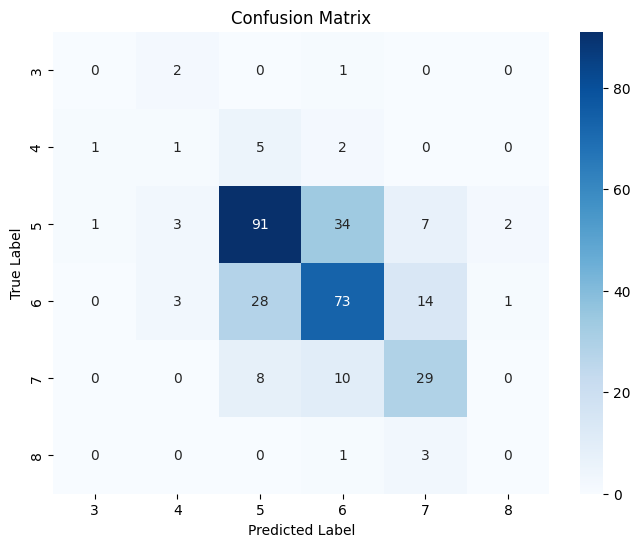

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

# Display Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Test predictions on new sample data points

### Test Predictions on New Sample Data Points

To see how our trained `KNeighborsClassifier` performs on individual, unseen data, we'll create a few hypothetical wine samples. It's crucial to remember that these new samples must have the same features and be scaled using the *same scaler* that was used for the training data.

In [54]:
import pandas as pd

# Create some new sample data points (replace with actual new data if available)
# Ensure these have the same columns as X (wine_quality.drop('quality', axis=1))
new_samples_data = {
    'fixed acidity': [7.0, 8.5, 6.5, 9.0],
    'volatile acidity': [0.27, 0.60, 0.40, 0.80],
    'citric acid': [0.36, 0.20, 0.25, 0.00],
    'residual sugar': [2.0, 2.5, 1.8, 3.0],
    'chlorides': [0.070, 0.080, 0.065, 0.090],
    'free sulfur dioxide': [12.0, 30.0, 10.0, 40.0],
    'total sulfur dioxide': [45.0, 100.0, 35.0, 150.0],
    'density': [0.996, 0.998, 0.995, 0.999],
    'pH': [3.30, 3.20, 3.40, 3.10],
    'sulphates': [0.65, 0.80, 0.50, 0.95],
    'alcohol': [10.0, 9.5, 11.0, 8.8]
}

new_samples_df = pd.DataFrame(new_samples_data)

print("New Sample Data Points:")
display(new_samples_df)

# Scale the new samples using the *same* scaler fitted on the training data
new_samples_scaled = scaler.transform(new_samples_df)

# Make predictions using the best_knn_model
predictions = best_knn_model.predict(new_samples_scaled)

print("\nPredicted Quality for New Samples:")
for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: Predicted Quality = {pred}")


New Sample Data Points:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,2.0,0.070,12.0,45.0,0.996,3.3,0.65,10.0
1,8.5,0.60,0.20,2.5,0.080,30.0,100.0,0.998,3.2,0.80,9.5
2,6.5,0.40,0.25,1.8,0.065,10.0,35.0,0.995,3.4,0.50,11.0
3,9.0,0.80,0.00,3.0,0.090,40.0,150.0,0.999,3.1,0.95,8.8



Predicted Quality for New Samples:
Sample 1: Predicted Quality = 7
Sample 2: Predicted Quality = 6
Sample 3: Predicted Quality = 5
Sample 4: Predicted Quality = 5
